# Memory Selection for Agents

Routing each sub-task to the RIGHT memory backend, with a planner + retrieval + memory agent in LangGraph.

| Primitive | What it is | Why it is here |
|-----------|------------|----------------|
| `PlanStep` | `(task, memory)` pair | The planner's atomic unit of work |
| `InMemoryVectorStore` | Tiny LangChain vector store, no deps | Demo-grade vector memory; swap to `Chroma` for prod |
| `sqlite` | Stdlib structured store | Tabular memory the agent can read with safe `SELECT`s |
| `MessagesState` | LangGraph chat-history state | Short-term working memory across a thread |
| `StateGraph` | LangGraph state-machine container | The plan -> route -> retrieve -> synthesize loop |

We will use `InMemoryVectorStore` and a `:memory:` SQLite for zero-setup retrieval; the **same agent graph** later runs against `Chroma` and a real Postgres without changing the routing logic. In this demonstration, we are trying to explore WHICH memory the agent should consult, not HOW each memory is implemented.

## Setup

In [12]:
# !pip install -q langchain langchain-google-genai langchain-openai langchain-anthropic langgraph langchain-community

from langchain.chat_models import init_chat_model
from langchain.embeddings import init_embeddings
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, List, Literal, Dict, Any
from pydantic import BaseModel, Field
import os, json, sqlite3

import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# os.environ['GEMINI_API_KEY']  # the variable for API key

llm   = init_chat_model('gpt-4o', model_provider='openai', temperature=0)
# llm   = init_chat_model('gemini-2.5-flash', model_provider='google_genai', temperature=0)

embed = init_embeddings('sentence-transformers/all-MiniLM-L6-v2', provider='huggingface')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## The four memory backends

Now let's build the four memories the router will choose between. Each one is a tiny class with the same shape, a `search(query)` method that returns evidence dicts, so the agent can call them uniformly.

Now, we will
- build a **`VectorMemory`** on `InMemoryVectorStore` seeded with 9 unstructured KB notes,
- build a **`SqliteStore`** on stdlib `sqlite3` seeded with users, orders, and prices,
- build a **`ProceduralMemory`** dict of named playbooks (prompt templates),
- build a **short-term** message buffer that mirrors `MessagesState` for in-thread context,
- print one search from each so the shapes are visible before we wire the router on top.

First, the **`VectorMemory`**, long-form prose chunks (runbooks, how-tos, post-mortems) indexed by similarity. This is the classic RAG store: good for *unstructured* questions where the answer paraphrases existing text.

In [3]:
# 9 KB notes engineered so each one is the unique best hit for a different query.
KB_DOCS = [
    ('kb-001', 'Reset a Locked Account',
     'Locked accounts emit error code LCK-17. Confirm the registered email, then run the reset flow. Never reset on phone alone.'),
    ('kb-002', 'Bulk Export Tickets',
     'Pro tier and above can export via /export/tickets?range=... . Results paginate at 500 rows; use the cursor param.'),
    ('kb-003', 'Search Outage Post-Mortem 2025-09',
     'A stale Elasticsearch snapshot caused beta_search_v2 to return empty hits for 41 minutes.'),
    ('kb-004', 'Escalate to Tier-2 Engineering',
     'Attach request-id, last 50 log lines, and a reproduction URL. Tier-2 SLA starts only after all three are present.'),
    ('kb-005', 'Email Bounce Spike Runbook',
     'If bounce rate exceeds 3 percent, pause non-transactional sends and check SPF/DKIM alignment.'),
    ('kb-006', 'Intermittent 502s on /api/v2/search',
     'Historically caused by keep-alive misconfig on the edge proxy. Compare upstream_cx_total vs upstream_cx_destroy.'),
    ('kb-007', 'Data Retention Policy',
     'Ticket bodies retained 24 months. Attachments 12 months. PII scrubbed on close unless legal hold active.'),
    ('kb-008', 'Auth Service Degradation Runbook',
     'p99 login latency over 1.5s triggers gradual traffic shift to backup region. Watch error budget for 15 min.'),
    ('kb-009', 'Feature Flag Audit Log How-To',
     'Audit log shows (actor, flag, user_id, old, new, ts). A null actor means a scripted rollout, not a human.'),
]

class VectorMemory:
    """Vector-backed unstructured memory. We expose a uniform search() so the
    router can treat every memory the same way regardless of internals."""
    def __init__(self, embed_model):
        docs = [Document(page_content=t, metadata={'doc_id': d, 'title': ti}) for d, ti, t in KB_DOCS]
        self.store = InMemoryVectorStore.from_documents(docs, embedding=embed_model)
    def search(self, query: str, k: int = 2) -> List[Dict[str, Any]]:
        hits = self.store.similarity_search(query, k=k)
        return [{'source': 'vector', 'doc_id': d.metadata['doc_id'],
                 'title': d.metadata['title'], 'content': d.page_content} for d in hits]

vector_mem = VectorMemory(embed)
print('Vector memory size:', len(KB_DOCS))

Vector memory size: 9


Next, the **`SqliteStore`**, structured tabular memory backed by stdlib `sqlite3`. The router sends *aggregate* and *id-lookup* questions here because vector retrieval cannot count or join.

In [4]:
# Stdlib sqlite, in-memory db, seeded with users / orders / prices.
USERS = [
    ('u-17', 'Alice Chen',    'Free'),
    ('u-23', 'Brian Patel',   'Pro'),
    ('u-42', 'Dmitri Volkov', 'Pro'),
    ('u-55', 'Elena Park',    'Enterprise'),
]
ORDERS = [
    ('o-1001', 'u-42', 'open',    'Search returns empty hits',         '2026-04-01'),
    ('o-1002', 'u-42', 'open',    'Refund follow-up',                  '2026-04-05'),
    ('o-1003', 'u-42', 'closed',  'Pro-tier export limit',             '2026-03-18'),
    ('o-1004', 'u-42', 'pending', 'Billing escalation invoice 9981',   '2026-04-09'),
    ('o-1005', 'u-23', 'open',    'OAuth callback mismatch',           '2026-04-03'),
    ('o-1006', 'u-17', 'open',    'Cannot create workspace',           '2026-04-10'),
    ('o-1007', 'u-55', 'closed',  'Audit log truncated',               '2026-04-02'),
]
PRICES = [
    ('Pro',        49,  'per user per month'),
    ('Enterprise', 199, 'per user per month, 20-seat minimum'),
]

SQL_SCHEMA = '''Tables:
  users(user_id TEXT PK, name TEXT, tier TEXT)   -- tier in (Free, Pro, Enterprise)
  orders(order_id TEXT PK, user_id TEXT FK, status TEXT, subject TEXT, created TEXT)
    -- status in (open, closed, pending)
  prices(tier TEXT PK, dollars INTEGER, note TEXT)
'''

Now the store class. Note `check_same_thread=False` so LangGraph workers can read it from any thread, and an UPPER_CASE `SQL_PROMPT` constant so the NL-to-SQL prompt is one place to tune.

In [5]:
SQL_PROMPT = '''You convert support questions into ONE safe read-only SQLite SELECT. 
Schema:
{schema}

Question: {question}
Return only the SELECT statement, no semicolons, no DDL, no DML.'''

class SqlPlan(BaseModel):
    """Structured SQL output keeps prose out of the executed query."""
    sql: str = Field(..., description='A single safe SELECT statement, no DDL/DML.')
    explanation: str = Field(..., description='One-sentence summary of what it fetches.')

class SqliteStore:
    """Structured memory backed by stdlib sqlite3 + a tiny NL-to-SQL bridge."""
    def __init__(self):
        self.conn = sqlite3.connect(':memory:', check_same_thread=False)
        cur = self.conn.cursor()
        cur.executescript('''
            CREATE TABLE users  (user_id TEXT PRIMARY KEY, name TEXT, tier TEXT);
            CREATE TABLE orders (order_id TEXT PRIMARY KEY, user_id TEXT, status TEXT, subject TEXT, created TEXT);
            CREATE TABLE prices (tier TEXT PRIMARY KEY, dollars INTEGER, note TEXT);
        ''')
        cur.executemany('INSERT INTO users  VALUES (?, ?, ?)',          USERS)
        cur.executemany('INSERT INTO orders VALUES (?, ?, ?, ?, ?)',    ORDERS)
        cur.executemany('INSERT INTO prices VALUES (?, ?, ?)',          PRICES)
        self.conn.commit()
    def search(self, query: str) -> List[Dict[str, Any]]:
        # NL -> SQL via structured output, then a SELECT-only safety prefix check.
        chain = llm.with_structured_output(SqlPlan)
        plan: SqlPlan = chain.invoke(SQL_PROMPT.format(schema=SQL_SCHEMA, question=query))
        sql = plan.sql.strip().rstrip(';')
        if not sql.lower().lstrip().startswith('select'):
            return [{'source': 'db', 'error': 'non-select rejected', 'sql': sql}]
        cur  = self.conn.execute(sql)
        cols = [c[0] for c in cur.description]
        rows = [dict(zip(cols, r)) for r in cur.fetchall()]
        return [{'source': 'db', 'sql': sql, 'explanation': plan.explanation, 'rows': rows}]

db_mem = SqliteStore()
print('Sqlite memory ready: tables=users, orders, prices')

Sqlite memory ready: tables=users, orders, prices


Now **`ProceduralMemory`**, a tiny dict of named playbooks. These are *prompt templates* the agent can stitch into its working context when the user asks a how-do-I question with a known sequence of steps.

In [6]:
PLAYBOOKS = {
    'password_reset': {
        'description': 'Reset a user password end-to-end including identity verification.',
        'steps': [
            'Confirm the user registered email via a one-time code.',
            'Invalidate all active sessions for the account.',
            'Trigger the reset-link email from the admin console.',
            'Log the reset in the audit ledger with the agent id.',
        ],
    },
    'escalate_billing': {
        'description': 'Escalate a Pro-tier billing dispute to the finance on-call.',
        'steps': [
            'Gather the invoice id, disputed line items, and user tier.',
            'Open a P2 ticket in the billing-escalations queue.',
            'Page the finance on-call via the rotation schedule.',
            'Update the customer within one business hour.',
        ],
    },
    'create_ticket': {
        'description': 'Create a new support ticket on behalf of a user.',
        'steps': [
            'Collect the user id, contact email, and issue summary.',
            'Classify severity using the standard S1-S4 rubric.',
            'POST to /tickets with the serialized payload.',
            'Send the ticket id back to the user for tracking.',
        ],
    },
}

class ProceduralMemory:
    """Named playbooks. Token-overlap matching keeps it dependency-free; swap for
    embeddings when the catalog grows past a few dozen entries."""
    def __init__(self, playbooks: Dict[str, Dict[str, Any]]):
        self.playbooks = playbooks
    def search(self, query: str, n: int = 1) -> List[Dict[str, Any]]:
        q_tokens = {t for t in query.lower().split() if len(t) > 2}
        scored = []
        for name, pb in self.playbooks.items():
            hay   = (name + ' ' + pb['description'] + ' ' + ' '.join(pb['steps'])).lower()
            score = sum(1 for t in q_tokens if t in hay)
            if score:
                scored.append((score, name, pb))
        scored.sort(key=lambda x: x[0], reverse=True)
        return [{'source': 'procedural', 'name': nm,
                 'description': pb['description'], 'steps': pb['steps']}
                for _, nm, pb in scored[:n]]

proc_mem = ProceduralMemory(PLAYBOOKS)
print('Procedural memory size:', len(PLAYBOOKS))

Procedural memory size: 3


Finally, **short-term** memory, the conversation buffer for the current thread. We use a list of message dicts shaped exactly like `MessagesState` so the same idea lifts to a graph-level checkpointer in production.

In [7]:
class ShortTermMemory:
    """Per-thread chat buffer. Mirrors LangGraph MessagesState so promotion to
    a checkpointer-backed thread is a one-line swap."""
    def __init__(self):
        self.messages: List[Dict[str, str]] = []
    def remember(self, role: str, content: str) -> None:
        self.messages.append({'role': role, 'content': content})
    def search(self, query: str, n: int = 3) -> List[Dict[str, Any]]:
        # Linear substring scan -- the buffer is small by construction.
        q = query.lower()
        hits = [m for m in self.messages if q in m['content'].lower()]
        return [{'source': 'short_term', 'role': m['role'], 'content': m['content']}
                for m in hits[-n:]]

short_mem = ShortTermMemory()
short_mem.remember('user', 'Earlier I mentioned my account id is u-42 and I am on Pro tier.')
short_mem.remember('assistant', 'Got it -- I will remember u-42 and Pro tier for follow-up turns.')
print('Short-term memory turns:', len(short_mem.messages))

Short-term memory turns: 2


Let's confirm each memory returns evidence in the same dict shape. Every section ends on a print, so we fan out one query per backend below.

In [8]:
print('---- vector ----')
for ev in vector_mem.search('what is the runbook for empty search results', k=1):
    print(f"  [{ev['source']}] {ev['title']}: {ev['content'][:100]}...")

print('---- procedural ----')
for ev in proc_mem.search('how do I escalate a billing dispute'):
    print(f"  [{ev['source']}] {ev['name']}: {ev['steps'][0]}")

print('---- short_term ----')
for ev in short_mem.search('u-42'):
    print(f"  [{ev['source']}] {ev['role']}: {ev['content'][:90]}...")

---- vector ----
  [vector] Search Outage Post-Mortem 2025-09: A stale Elasticsearch snapshot caused beta_search_v2 to return empty hits for 41 minutes....
---- procedural ----
  [procedural] escalate_billing: Gather the invoice id, disputed line items, and user tier.
---- short_term ----
  [short_term] user: Earlier I mentioned my account id is u-42 and I am on Pro tier....
  [short_term] assistant: Got it -- I will remember u-42 and Pro tier for follow-up turns....


## The `MemoryChoice` router

Now let's build the brain that picks WHICH memory to consult. Asking the LLM to free-form pick a backend is a recipe for hallucinated source names. Instead, we use `with_structured_output` against a `Literal[...]` enum.

Now, we will
- define the **`MemoryChoice`** Pydantic schema with a `Literal[...]` over the five backends,
- write a single UPPER_CASE `ROUTER_PROMPT` that names each backend's purpose,
- bind it once with `llm.with_structured_output(MemoryChoice)`,
- demo the router on five queries that should each route to a different backend.

In [9]:
class MemoryChoice(BaseModel):
    """Structured routing decision. The Literal enum is the stability lever:"""
    """the LLM CANNOT invent a new source name, so the dispatcher never hits a KeyError."""
    target: Literal['vector', 'db', 'short_term', 'procedural', 'general'] = Field(
        ..., description='The single memory backend to query for this sub-task.')
    reason: str = Field(
        ..., description='One short sentence justifying the choice.')

The schema **is** the control flow, the router cannot return a value the dispatcher does not handle. The `general` slot is a safety hatch for sub-tasks that need no retrieval at all (e.g. greetings, summarisation).

In [10]:
ROUTER_PROMPT = '''You are a memory router for a support agent. Given a sub-task, pick the SINGLE best backend. 
Choices:
- vector:     unstructured prose -- runbooks, how-to articles, post-mortems.
- db:         structured aggregates over users/orders/prices (counts, joins, filters).
- short_term: facts mentioned earlier in THIS conversation (e.g. you said X).
- procedural: step-by-step playbooks (how do I escalate, how do I reset).
- general:    no retrieval needed -- pure reasoning, summarisation, or greeting.

Sub-task: {task}

Return exactly one target and a short reason. Do not hedge.'''

router_chain = llm.with_structured_output(MemoryChoice)

def route_task(task: str) -> MemoryChoice:
    """Memory selection for one sub-task. Same call shape regardless of backend --"""
    """the router only emits a Literal, never a free-form string."""
    return router_chain.invoke(ROUTER_PROMPT.format(task=task))

Let's stress-test the router on five sub-tasks designed to land on five different backends. The `[target:8]` width-padded print makes it easy to scan whether routing is stable.

In [13]:
DEMO_TASKS = [
    'How many open orders does u-42 have?',
    'What is the runbook for the auth service degradation?',
    'How do I escalate a Pro-tier billing dispute step by step?',
    'What did I tell you earlier about my account id?',
    'Just say hello to the user politely.',
]

print('---- memory selection demo ----')
for t in DEMO_TASKS:
    decision = route_task(t)
    print(f"  [{decision.target:<10}] {t}")
    print(f"             reason: {decision.reason[:90]}")

---- memory selection demo ----
  [db        ] How many open orders does u-42 have?
             reason: The task requires querying structured data about user orders.
  [vector    ] What is the runbook for the auth service degradation?
             reason: Runbooks are typically stored as unstructured prose documents.
  [procedural] How do I escalate a Pro-tier billing dispute step by step?
             reason: Escalating a billing dispute requires following a specific set of steps.
  [short_term] What did I tell you earlier about my account id?
             reason: The sub-task requires recalling specific information mentioned earlier in the conversation
  [general   ] Just say hello to the user politely.
             reason: A polite greeting requires no retrieval, just pure reasoning.


## The `PlanStep` planner

Real user requests rarely fit one memory. "Show u-42's open orders and our refund policy" needs a `db` query AND a `vector` lookup. Now let's add a planner that decomposes the request into typed `PlanStep`s, each pre-annotated with the memory backend it should use.

Now, we will
- define a **`PlanStep`** Pydantic schema reusing the same `Literal[...]` from the router,
- define a **`Plan`** wrapper holding 1..4 ordered steps,
- write a `PLANNER_PROMPT` that asks the LLM to both decompose AND pre-route in one structured call,
- run the planner on a compound request and print the plan .

In [14]:
class PlanStep(BaseModel):
    """One atomic sub-task plus the memory it should consult. Pre-annotating"""
    """the memory choice here means the executor never has to re-route mid-flight."""
    task: str = Field(..., description='Self-contained sub-task in plain English.')
    memory: Literal['vector', 'db', 'short_term', 'procedural', 'general'] = Field(
        ..., description='Which memory backend should answer this sub-task.')

class Plan(BaseModel):
    """Ordered list of 1..4 PlanSteps. The size cap stops the planner from"""
    """over-fragmenting simple requests into a dozen one-token sub-tasks."""
    steps: List[PlanStep] = Field(..., description='1..4 ordered PlanSteps.')

Reusing the same `Literal[...]` between `MemoryChoice` and `PlanStep` keeps the schema honest. The planner cannot invent a backend name the router/dispatcher doesn't know about.

In [15]:
PLANNER_PROMPT = '''You are a planning agent for a support system. Decompose the user request into 1 to 4 
self-contained sub-tasks AND pre-route each one to the memory backend that should answer it.

Memory backends:
- vector:     unstructured runbooks / how-to articles / post-mortems.
- db:         structured tabular data -- users, orders, prices.
- short_term: facts the user mentioned earlier in THIS conversation.
- procedural: known step-by-step playbooks.
- general:    no retrieval needed -- greetings, pure reasoning.

Preserve any user ids (like u-42) in every sub-task that needs them.

User request: {request}'''

planner_chain = llm.with_structured_output(Plan)

def make_plan(request: str) -> Plan:
    """One LLM call returns BOTH decomposition and per-step memory selection."""
    return planner_chain.invoke(PLANNER_PROMPT.format(request=request))

Let's plan a deliberately compound request that should fan out to multiple memories. We expect at least one `db` step (open orders) and one `vector` or `procedural` step (refund / runbook).

In [16]:
compound_q = 'For u-42, how many open orders are there, and what is our written refund policy from the runbook?'
plan = make_plan(compound_q)

print('---- plan ----')
print('REQUEST:', compound_q)
for i, s in enumerate(plan.steps, 1):
    print(f"  step {i}  [{s.memory:<10}] {s.task}")

---- plan ----
REQUEST: For u-42, how many open orders are there, and what is our written refund policy from the runbook?
  step 1  [db        ] Retrieve the number of open orders for user u-42.
  step 2  [vector    ] Find the written refund policy from the runbook.


## The full agent graph

Now let's wire everything into a `StateGraph`: the planner emits steps, the router (already baked into each step) drives the dispatcher, the dispatcher fans out to the right memory, and a final synthesizer fuses the evidence into a cited answer.

Now, we will
- define an **`AgentState`** TypedDict that flows through the graph (request, plan, evidence, answer, trace),
- write `plan_node`, `route_node`, `retrieve_node`, `synthesize_node`, one concept per snake_case node,
- assemble them with `StateGraph` and `add_edge`,
- compile and inspect the node list.

In [17]:
class AgentState(TypedDict, total=False):
    """Shared graph state. total=False so early nodes can populate fields incrementally."""
    request:  str
    plan:     List[Dict[str, Any]]   # serialised PlanSteps for trace-friendliness
    evidence: List[Dict[str, Any]]
    answer:   str
    trace:    List[Dict[str, Any]]

The `plan_node` calls our planner and stashes the structured plan into state. We serialise to plain dicts so the trace is JSON-renderable without custom encoders.

In [18]:
def plan_node(state: AgentState) -> Dict[str, Any]:
    """Decompose the request into PlanSteps and record them in trace."""
    p = make_plan(state['request'])
    plan_dicts = [{'task': s.task, 'memory': s.memory} for s in p.steps]
    trace = state.get('trace', []) + [{'node': 'plan', 'plan': plan_dicts}]
    return {'plan': plan_dicts, 'trace': trace}

The `route_node` is a no-op verifier in this graph because each `PlanStep` already carries its `memory` choice. We keep the node so the trace explicitly logs the routing decision the agent committed to.

In [19]:
def route_node(state: AgentState) -> Dict[str, Any]:
    """Echo the per-step memory choice into the trace. The planner pre-routed each step,"""
    """so this node only audits the decision rather than re-running the router."""
    routes = [{'task': s['task'], 'memory': s['memory']} for s in state['plan']]
    trace  = state.get('trace', []) + [{'node': 'route', 'routes': routes}]
    return {'trace': trace}

The `retrieve_node` is the dispatcher. A simple dict map from `Literal` value to memory instance keeps it open-closed: adding a new backend is a one-line entry plus a new `Literal` member upstream.

In [20]:
DISPATCH = {
    'vector':     lambda q: vector_mem.search(q, k=2),
    'db':         lambda q: db_mem.search(q),
    'procedural': lambda q: proc_mem.search(q),
    'short_term': lambda q: short_mem.search(q),
    'general':    lambda q: [{'source': 'general', 'note': 'no retrieval -- pure reasoning'}],
}

def retrieve_node(state: AgentState) -> Dict[str, Any]:
    """Run each PlanStep through the dispatcher and collect evidence dicts."""
    evidence: List[Dict[str, Any]] = []
    for step in state['plan']:
        handler = DISPATCH[step['memory']]
        items   = handler(step['task'])
        for it in items:
            it['_task'] = step['task']
            evidence.append(it)
    trace = state.get('trace', []) + [{'node': 'retrieve', 'evidence_count': len(evidence)}]
    return {'evidence': evidence, 'trace': trace}

The `synthesize_node` fuses everything. We serialise evidence as JSON in the prompt so the LLM can cite by index and source. The `SYNTH_PROMPT` is module-level (UPPER_CASE) so we can re-tune it in one place.

In [21]:
SYNTH_PROMPT = '''You are a support agent. Using ONLY the evidence below, answer the user. 
Cite the source of each claim in square brackets like [vector], [db], [procedural], or [short_term]. 
If evidence is insufficient, say so plainly.

User request: {request}

Evidence (JSON):
{evidence}'''

def synthesize_node(state: AgentState) -> Dict[str, Any]:
    """Fuse evidence into a final cited answer and mirror the turn into short-term memory."""
    rendered = json.dumps(state['evidence'], indent=2, default=str)
    resp = llm.invoke(SYNTH_PROMPT.format(request=state['request'], evidence=rendered))
    answer = getattr(resp, 'content', str(resp))
    short_mem.remember('user', state['request'])
    short_mem.remember('assistant', answer)
    trace = state.get('trace', []) + [{'node': 'synthesize', 'answer_len': len(answer)}]
    return {'answer': answer, 'trace': trace}

Now the assembly. Linear graph: plan -> route -> retrieve -> synthesize -> END. We compile and print the node list as a sanity check that no edges are missing.

In [22]:
builder = StateGraph(AgentState)
builder.add_node('plan',       plan_node)
builder.add_node('route',      route_node)
builder.add_node('retrieve',   retrieve_node)
builder.add_node('synthesize', synthesize_node)

builder.add_edge(START,        'plan')
builder.add_edge('plan',       'route')
builder.add_edge('route',      'retrieve')
builder.add_edge('retrieve',   'synthesize')
builder.add_edge('synthesize', END)

agent = builder.compile()
print('Graph compiled with nodes:', list(builder.nodes.keys()))

Graph compiled with nodes: ['plan', 'route', 'retrieve', 'synthesize']


Jupyter renders the compiled graph's mermaid diagram below, automatically. Use this during development to catch misrouted edges instantly.

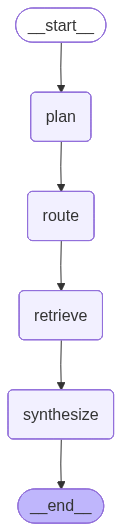

In [23]:
agent

## Demo runs across three different memories

Now let's invoke the agent on three realistic queries, each chosen so the planner routes to a DIFFERENT memory. We will print the trace, the plan with per-step backend, and the final cited answer.

Now, we will
- run a query that should hit `db` (counting u-42's open orders),
- run a query that should hit `vector` (an unstructured how-to lookup),
- run a compound query that should hit BOTH `procedural` and `vector`,
- print each run with the trace, plan, and final answer.

In [24]:
DEMO_QUERIES = [
    'How many open orders does u-42 currently have?',
    'What is our runbook for an email bounce spike?',
    'How do I escalate a Pro-tier billing issue, and is there a related runbook on bulk-export issues?',
]

def run_one(request: str) -> Dict[str, Any]:
    """Single end-to-end agent run. Returns the final state for inspection."""
    initial: AgentState = {'request': request, 'evidence': [], 'trace': []}
    return agent.invoke(initial)

In [25]:
for i, q in enumerate(DEMO_QUERIES, 1):
    print(f'\n---- demo {i} ----')
    result = run_one(q)

    print('=== REQUEST ===')
    print(q)

    print('=== PLAN ===')
    for j, step in enumerate(result['plan'], 1):
        print(f"  step {j}  [{step['memory']:<10}] {step['task']}")

    print('=== EVIDENCE ===')
    for ev in result['evidence']:
        src = ev.get('source', '?')
        preview = {k: v for k, v in ev.items() if not k.startswith('_')}
        text = str(preview)
        if len(text) > 200:
            text = text[:197] + '...'
        print(f"  [{src:<10}] {text}")

    print('=== FINAL ANSWER ===')
    ans = result.get('answer', '')
    print(ans[:400] + ('...' if len(ans) > 400 else ''))


---- demo 1 ----
=== REQUEST ===
How many open orders does u-42 currently have?
=== PLAN ===
  step 1  [db        ] Retrieve the current number of open orders for user u-42.
=== EVIDENCE ===
  [db        ] {'source': 'db', 'sql': "SELECT COUNT(*) FROM orders WHERE user_id = 'u-42' AND status = 'open'", 'explanation': 'Counts open orders for user u-42.', 'rows': [{'COUNT(*)': 2}]}
=== FINAL ANSWER ===
User u-42 currently has 2 open orders [db].

---- demo 2 ----
=== REQUEST ===
What is our runbook for an email bounce spike?
=== PLAN ===
  step 1  [vector    ] Retrieve the runbook for handling an email bounce spike.
=== EVIDENCE ===
  [vector    ] {'source': 'vector', 'doc_id': 'kb-005', 'title': 'Email Bounce Spike Runbook', 'content': 'If bounce rate exceeds 3 percent, pause non-transactional sends and check SPF/DKIM alignment.'}
  [vector    ] {'source': 'vector', 'doc_id': 'kb-001', 'title': 'Reset a Locked Account', 'content': 'Locked accounts emit error code LCK-17. Confirm the re

### Adopting memory selection in production
- Always set `recursion_limit` on `StateGraph.invoke`. The default is 25 and unbounded re-planning loops are the #1 production agent failure .
- Keep `temperature=0` on the planner AND the router. Higher temperature increases the rate of malformed Pydantic responses and makes memory selection non-reproducible across runs.
- Reuse the SAME `Literal[...]` enum across `MemoryChoice` and `PlanStep`. Drift between them is the most common silent bug; the planner emits a backend name the dispatcher does not know about, and the run dies on a `KeyError`.
- Swap `InMemoryVectorStore` for a persistent store (`Chroma`, `pgvector`, `Pinecone`) and `:memory:` SQLite for a real DB before deploy. Every `VectorStore` implements the same retriever API, so the dispatcher does not change.

### Common pitfalls in memory routing
- The router can over-pick `general` to dodge retrieval. Mitigation: in the prompt, say `general` is ONLY for greetings or pure summarisation, never for factual questions.
- The planner can fragment a simple request into 4 trivial sub-tasks. Mitigation: cap `Plan.steps` at 4 in the schema (we did) AND tell the prompt that single-fact requests should return a one-step plan.
- Vector and DB look interchangeable for some queries (`What is our refund policy?`). Decide a tie-breaker in the router prompt; prefer `vector` for prose policies, `db` only for structured tabular questions.
- Short-term memory is per-thread, not global. A new `thread_id` starts the buffer fresh.